<a href="https://colab.research.google.com/github/Sshahsavar/credit-risk-modeling/blob/main/Part_0_Credit_Risk_Data_Foundation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Credit Risk Data Foundation: Lending Club Loans & Macroeconomic Drivers**

Part 0 of the credit risk series. It prepares the data for **Part 3 (LGD Modeling)** and **Part 4 (Macroeconomic Stress Testing)**.

---

* Project Overview & Data Source

Data Source: This project uses the Lending Club loan [dataset](https://www.kaggle.com/datasets/wordsforthewise/lending-club): about 2.26 million US consumer loans issued between 2007 and 2018. For each loan it has the application data and the full repayment outcome. Macroeconomic data (US and state unemployment rates, real GDP growth) is downloaded from the Federal Reserve Bank of St. Louis ([FRED](https://fred.stlouisfed.org/)).

Objective: To build one clean analytical dataset that supports all four risk parameters of the credit loss equation, $EL = PD \times LGD \times EAD$, plus a link to the economy for stress testing.

Why a new dataset? Parts 1 and 2 used the Home Credit dataset. It is excellent for PD modeling, but it cannot support the next two projects:

| Requirement | Needed for | Home Credit | Lending Club |
|---|---|---|---|
| Default flag + application features | PD | ✅ (`TARGET` = payment difficulties) | ✅ (`loan_status` = Charged Off) |
| Balance outstanding at default | EAD, LGD | ❌ | ✅ (`funded_amnt − total_rec_prncp`) |
| Money recovered after default | LGD | ❌ | ✅ (`recoveries`, `collection_recovery_fee`) |
| Calendar dates | stress testing, out-of-time validation | ❌ (only relative "days before application") | ✅ (`issue_d`, `last_pymnt_d`) |
| Borrower location | regional macro link | ❌ | ✅ (`addr_state`) |

Without recoveries, LGD can only be *assumed*, as Part 2 did with a fixed 60%. Without dates, defaults cannot be linked to unemployment. Lending Club is the one public dataset that covers all of these requirements.

---

* The Logic & Methodology

The pipeline mirrors how a bank builds a modeling data mart:

Data Loading from Google Drive: The raw Lending Club file (about 1.6 GB) is stored on Google Drive. We load only the columns needed, grouped into origination features, outcome fields and post-origination amounts.

Outcome Definition: Loan statuses are mapped to four outcome classes (default, paid, current, delinquent).

Event Timing: Each loan gets an exit date (default, prepayment or maturity) and an exit type. This turns a static snapshot into a time-to-event dataset, which is the foundation of the stress-testing model.

Leakage Control: Columns that describe the loan *after* origination (payments, recoveries) are needed for LGD and EAD. They must never enter a PD model, so we list them explicitly.

Macro Data Engineering: State-level unemployment is downloaded from FRED and aggregated to quarters, together with the 4-quarter change in unemployment and US GDP growth.

---

* Outputs & Key Facts

Outputs: `lc_clean.pkl` (loan-level table), `macro_state_q.csv` and `macro_us_q.csv` (quarterly macro drivers) and `as_of.txt` (snapshot date), all saved to the project folder on Google Drive.

Key Facts: The clean dataset holds **2,260,668 loans** issued between June 2007 and December 2018, observed at a **March 2019 snapshot**. Of these, **269,360 (11.9%) were charged off**, 47.7% were repaid and 38.9% were still current. The macro data covers **all 50 states plus DC**, quarterly from 2000Q1 to 2026Q2, so it includes both the 2008–09 recession and the 2020 COVID-19 shock.

---

Tech Stack: Python, Pandas, NumPy, Matplotlib, Google Colab, Google Drive, FRED.

# Step 1: Environment Setup & Data Loading
The raw data sits on Google Drive, so the first step is to mount Drive and point the notebook to the project folder. All outputs of this notebook are written back to the same folder, where the LGD and stress-testing notebooks pick them up.

**Before running:**
1. Download `accepted_2007_to_2018Q4.csv.gz` from the Kaggle page above.
2. Upload it to your Google Drive project folder.
3. Set `PROJECT_DIR` below to that folder.

The file is large, so we read only the 36 columns this project needs instead of all 151. This cuts memory use and loading time substantially.

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
warnings.filterwarnings('ignore')

# 1.1. Mount Google Drive and define the project folder
from google.colab import drive
drive.mount('/content/drive')
import google.colab.userdata
PROJECT_DIR = google.colab.userdata.get('credit_ris_DIR')

RAW_FILE = os.path.join(PROJECT_DIR, 'accepted_2007_to_2018Q4.csv')
FRED_DIR = os.path.join(PROJECT_DIR, 'fred')
os.makedirs(FRED_DIR, exist_ok=True)
print(f"Project folder: {PROJECT_DIR}")
print(f"Raw file found: {os.path.exists(RAW_FILE)}")

# 1.2. Define the columns to load, grouped by their role in the analysis
ORIGINATION_COLS = [   # known at approval -> safe for PD models
    'id', 'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose',
    'addr_state', 'dti', 'fico_range_low', 'fico_range_high', 'revol_util', 'revol_bal',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'mort_acc', 'application_type']
OUTCOME_COLS = ['loan_status', 'last_pymnt_d']
POST_ORIGINATION_COLS = [   # describe the future -> LGD/EAD only, NEVER in a PD model (leakage)
    'out_prncp', 'total_rec_prncp', 'recoveries', 'collection_recovery_fee', 'debt_settlement_flag']

# 1.3. Load the data
print("Loading Lending Club data (this takes 1-2 minutes)...")
header = pd.read_csv(RAW_FILE, nrows=0).columns
usecols = [c for c in ORIGINATION_COLS + OUTCOME_COLS + POST_ORIGINATION_COLS if c in header]
raw = pd.read_csv(RAW_FILE, usecols=usecols, low_memory=False)

print(f"Loaded Dataset Shape: {raw.shape}")
print("\nLast 3 rows (the file ends with summary rows that must be removed):")
display(raw.tail(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/Python Projects/Sample projects/Credit Default risk/All Lending Club loan
Raw file found: True
Loading Lending Club data (this takes 1-2 minutes)...
Loaded Dataset Shape: (2260701, 34)

Last 3 rows (the file ends with summary rows that must be removed):


,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,revol_util,total_acc,out_prncp,total_rec_prncp,recoveries,collection_recovery_fee,last_pymnt_d,application_type,mort_acc,debt_settlement_flag
2260698,88215728,14000.0,14000.0,60 months,14.49,329.33,C,C4,10+ years,MORTGAGE,...,54.0,22.0,8456.12,5543.88,0.0,0.0,Mar-2019,Individual,1.0,N
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2: 521953170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Conclusion:
The loader read **2,260,701 rows × 34 columns** and keeps only the fields required for PD, LGD, EAD and stress testing. Grouping the columns by role at load time is also a model-risk control: the post-origination fields (`recoveries`, `total_rec_prncp`, …) are flagged as leakage for any PD model from the very first cell.

The last rows of the file are not loans but summary lines ("Total amount funded in policy code 1: 1,465,324,575"). They are removed in the next step.

# Step 2: Data Cleaning & Outcome Definition
The raw Lending Club fields are stored as text in formats that models cannot use directly: `" 36 months"`, `"10+ years"`, `"Dec-2015"`. This step converts them into numbers and dates.

The most important decision is the **definition of default**. Lending Club reports a loan status for every loan at the snapshot date. We group the statuses into four outcomes:

| `loan_status` | Outcome | Meaning |
|---|---|---|
| Charged Off, Default, "Does not meet the credit policy. Status: Charged Off" | `default` | the loan was written off, so there is a loss |
| Fully Paid, "Does not meet the credit policy. Status: Fully Paid" | `paid` | repaid in full, early or at maturity |
| Current | `current` | still performing, outcome not yet known |
| In Grace Period, Late (16–30 days), Late (31–120 days) | `delinquent` | behind on payments, not yet charged off |

In [ ]:
print("--- Cleaning Loan Data ---")

# 1. Remove the summary rows at the end of the file
df = raw.dropna(subset=['loan_amnt']).copy()
del raw

# 2. Parse dates into monthly periods ("Dec-2015" -> 2015-12)
df['issue_m'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce').dt.to_period('M')
df['last_pymnt_m'] = pd.to_datetime(df['last_pymnt_d'], format='%b-%Y', errors='coerce').dt.to_period('M')

# 3. Convert text fields into numbers
df['term_m'] = df['term'].str.extract(r'(\d+)').astype(int)                        # " 36 months" -> 36
for col in ['int_rate', 'revol_util']:                                              # some versions keep a '%'
    if df[col].dtype == object:
        df[col] = df[col].str.rstrip('%').astype(float)
df['emp_years'] = (df['emp_length'].replace({'< 1 year': '0', '10+ years': '10'})
                   .str.extract(r'(\d+)')[0].astype(float))                          # "10+ years" -> 10
df['fico'] = (df['fico_range_low'] + df['fico_range_high']) / 2                     # midpoint of FICO range

# 4. Map loan statuses into four outcome classes
status = df['loan_status'].str.lower()
df['outcome'] = np.select(
    [status.str.contains('charged off') | status.eq('default'),
     status.str.contains('fully paid'),
     status.eq('current')],
    ['default', 'paid', 'current'], default='delinquent')

print(f"Clean Dataset Shape: {df.shape}")
print(f"Issue dates: {df['issue_m'].min()} to {df['issue_m'].max()}\n")
print("--- Outcome Distribution ---")
display(pd.DataFrame({'Loans': df['outcome'].value_counts(),
                      'Share': df['outcome'].value_counts(normalize=True).round(4)}))

--- Cleaning Loan Data ---
Clean Dataset Shape: (2260668, 40)
Issue dates: 2007-06 to 2018-12

--- Outcome Distribution ---


,Loans,Share
outcome,,
paid,1078739,0.4772
current,878317,0.3885
default,269360,0.1192
delinquent,34252,0.0152


## Conclusion:
Cleaning removed **33 non-loan rows**, leaving **2,260,668 loans** with issue dates from 2007-06 to 2018-12. The outcome distribution shapes everything that follows:

1. **Paid: 1,078,739 loans (47.7%).** These are the completed "good" outcomes.

2. **Current: 878,317 loans (38.9%).** Their final outcome is unknown. A naive default rate that counted them as "good" would understate risk, especially for the 2016–2018 vintages. The next step handles this with event timing and censoring. These current loans are also the starting portfolio for the stress test in Part 4.

3. **Default: 269,360 loans (11.9%).** These charged-off loans are the modeling sample for LGD in Part 3. Only for them can we observe how much was recovered after default.

4. **Delinquent: 34,252 loans (1.5%).** They are behind on payments but not yet charged off. They are on the way to default, but their outcome is not final.

# Step 3: Event Timing: Default, Prepayment & Censoring
The Lending Club file is a **snapshot**: every status is measured at one extraction date, the `AS_OF` date. A stress test, however, needs to know *when* each event happened, so that default rates can be linked to the economic conditions of that quarter.

The data has no explicit default date, so we use the standard approximation from the last payment:

* **Default date** = last payment month + 4 months. If the last payment was in month $m$, the instalment of month $m+1$ is missed, and the loan reaches **90 days past due** around month $m+4$. That is the Basel definition of default.
* **Paid-off date** = last payment month. If this is at least 3 months before contractual maturity, the loan was **prepaid**; otherwise it **matured**.
* **Current and delinquent loans** have not exited yet. They are **censored** at the snapshot date.

We also compute the two quantities LGD requires:

$$EAD_i = \text{Funded}_i - \text{PrincipalRepaid}_i \qquad\qquad NR_i = \text{Recoveries}_i - \text{CollectionFee}_i$$

In [ ]:
print("--- Constructing Event Timing ---")

DEFAULT_LAG_MONTHS = 4   # last payment + 4 months ~ 90 days past due

def month_number(period_series):
    """Period[M] -> integer month count, used for fast date arithmetic (NaN-safe)."""
    return (period_series.dt.year * 12 + period_series.dt.month).where(period_series.notna())

# 1. Snapshot date = latest payment month in the file
AS_OF = df['last_pymnt_m'].max()
print(f"Snapshot (AS_OF) date: {AS_OF}")

# 2. Exit date for defaulted and paid loans
is_default = df['outcome'].eq('default')
is_paid = df['outcome'].eq('paid')
df['exit_m'] = pd.Series(pd.NaT, index=df.index).astype('period[M]')
df.loc[is_default, 'exit_m'] = df.loc[is_default, 'last_pymnt_m'].fillna(df.loc[is_default, 'issue_m']) + DEFAULT_LAG_MONTHS
df.loc[is_paid, 'exit_m'] = df.loc[is_paid, 'last_pymnt_m']

# 3. Exit type: default / prepaid / matured / censored
months_before_maturity = month_number(df['issue_m']) + df['term_m'] - month_number(df['exit_m'])
df['exit_type'] = np.select(
    [is_default, is_paid & (months_before_maturity >= 3), is_paid],
    ['default', 'prepaid', 'matured'], default='censored')
df['mob_exit'] = month_number(df['exit_m']) - month_number(df['issue_m'])   # months on book at exit

# 4. Exposure at default and net recovery
df['ead'] = (df['funded_amnt'] - df['total_rec_prncp']).clip(lower=0)
df['net_recovery'] = df['recoveries'] - df['collection_recovery_fee']

print("\n--- Exit Type Distribution ---")
display(df['exit_type'].value_counts().to_frame('Loans'))

# 5. Data quality checks
print("--- Data Quality Checks ---")
checks = {
    'Loan IDs are unique': df['id'].is_unique,
    'Funded amount is positive': (df['funded_amnt'] > 0).all(),
    'EAD of defaults is non-negative': (df.loc[is_default, 'ead'] >= 0).all(),
    'Recoveries are non-negative': (df['recoveries'].fillna(0) >= 0).all(),
    'Exit date is not before issue date': (df['mob_exit'].dropna() >= 0).all(),
    'Every default has an exit date': df.loc[is_default, 'exit_m'].notna().all(),
}
for check, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}  {check}")

--- Constructing Event Timing ---
Snapshot (AS_OF) date: 2019-03

--- Exit Type Distribution ---


,Loans
exit_type,
censored,912569
prepaid,821174
default,269360
matured,257565


--- Data Quality Checks ---
PASS  Loan IDs are unique
PASS  Funded amount is positive
PASS  EAD of defaults is non-negative
PASS  Recoveries are non-negative
PASS  Exit date is not before issue date
PASS  Every default has an exit date


## Conclusion:
With a snapshot date of **March 2019**, every loan now carries an exit type and an exit date, and all six data-quality checks **PASS**. The static snapshot has become a **time-to-event dataset**:

| Exit Type | Loans | Meaning |
|---|---|---|
| Censored | 912,569 | still open (current or delinquent) at the snapshot |
| Prepaid | 821,174 | repaid at least 3 months early |
| Default | 269,360 | charged off; default dated at last payment + 4 months |
| Matured | 257,565 | repaid on schedule |

1. **Prepayment is the dominant exit.** 76% of repaid loans (821,174 of 1,078,739) were paid off early. A stress test that ignored prepayment would keep too much balance exposed to default, which is why Part 4 models prepayment as a competing risk.

2. **Censored loans are kept, not dropped.** 40% of the loans have not exited. They survived up to the snapshot, and dropping them would overstate default risk, a form of survivorship bias.

3. **LGD building blocks are ready.** `ead` and `net_recovery` are available for all 269,360 defaults, the input to Part 3.

# Step 4: Exploratory View of Defaults Over Time
Before modeling, we look at how lending volume and defaults developed over time. There is a common trap here: the **censoring bias**.

A naive "default rate by issue year" makes recent vintages look safe, only because their loans have not had enough time to default. We therefore show:
1. Funded volume by issue year: how the portfolio grew.
2. The default share among *completed* loans only (defaulted or paid). This is still biased for recent years, because early payers finish first.
3. Default events by **calendar quarter**. This is the series the stress-testing model will explain with macroeconomic variables.

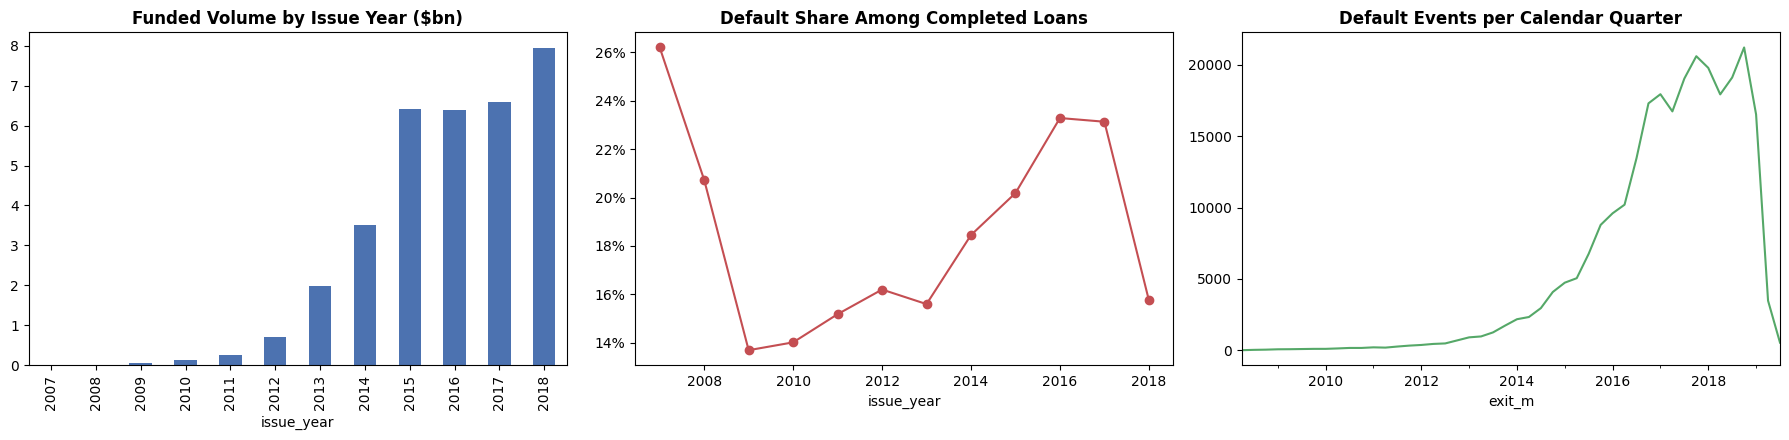

In [ ]:
df['issue_year'] = df['issue_m'].dt.year
completed = df[df['outcome'].isin(['default', 'paid'])]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# 1. Funded volume
(df.groupby('issue_year')['funded_amnt'].sum() / 1e9).plot.bar(ax=axes[0], color='#4C72B0')
axes[0].set_title('Funded Volume by Issue Year ($bn)', fontweight='bold')

# 2. Default share among completed loans
completed.groupby('issue_year')['outcome'].apply(lambda s: (s == 'default').mean()).plot(
    ax=axes[1], marker='o', color='#C44E52')
axes[1].set_title('Default Share Among Completed Loans', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

# 3. Default events per calendar quarter
df.loc[is_default, 'exit_m'].dt.asfreq('Q').value_counts().sort_index().plot(ax=axes[2], color='#55A868')
axes[2].set_title('Default Events per Calendar Quarter', fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusion:
The charts reveal three forces that a stress-testing model must separate:

1. **Explosive portfolio growth.** Annual funded volume was below $1bn until 2012, then rose to about $6.4bn in 2015 and $8bn in 2018. The 2007–2011 loans, the only ones that lived through the 2008–09 recession and its aftermath, are a tiny fraction of the book. This is the main limitation of the dataset for downturn analysis.

2. **Vintage quality drifted upwards.** Among completed loans, the default share was about 26% for 2007 and 21% for 2008 issues. It fell to about 14% for the 2009–2010 vintages, when underwriting was tight after the crisis. It then climbed steadily to about **23% for the 2016–2017 vintages**, as Lending Club expanded into riskier borrowers. The 2018 figure (16%) is biased downward, because its completed loans are mostly early prepayments. This upward drift happened **while unemployment was falling**. Unless it is controlled for, the drift can mislead any model that links defaults to unemployment (see Part 4).

3. **Default events follow the book, and are truncated at the end.** Default events per quarter rose from almost zero to about 21,000 by late 2018, mainly because the book grew. The model in Part 4 therefore works with default *rates* per loan, not with counts. The sharp drop after 2018Q4 is not a real improvement. Defaults near the snapshot are not yet visible, because a default is dated 4 months after the last payment. Part 4 therefore ends its estimation panel two quarters before the snapshot (`CO_LAG_Q = 2`).

# Step 5: Macroeconomic Data Engineering (FRED)
Stress testing links credit losses to the economy through **macroeconomic drivers**. For unsecured consumer loans, the dominant driver is **unemployment**: job loss is the most common reason a borrower stops paying.

We download three kinds of series from FRED (no API key needed):

| FRED Series | Meaning | Frequency |
|---|---|---|
| `UNRATE` | US unemployment rate (%) | monthly |
| `{ST}UR` (e.g. `CAUR`, `NYUR`) | unemployment rate of each US state (%) | monthly |
| `A191RL1Q225SBEA` | US real GDP growth (% annualized) | quarterly |

State-level unemployment is the key design choice. Lending Club's history contains only one recession, so time variation alone is thin. Differences *between states in the same quarter* (Nevada vs. Texas, say) give the model much more information about how unemployment affects defaults.

The monthly series are averaged to quarters. We also compute the 4-quarter change in unemployment, $\Delta_4 UR_{s,t} = UR_{s,t} - UR_{s,t-4}$, because a *rising* unemployment rate signals fresh job losses. Every download is cached on Drive, so the notebook also runs offline.

--- Downloading Macroeconomic Data from FRED ---
Downloaded 51 states, 106 US quarters (2000Q1 to 2026Q2)


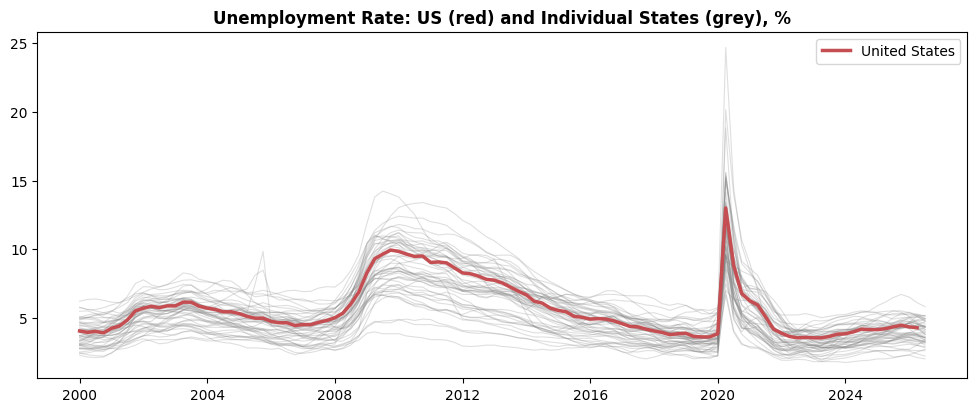

In [ ]:
print("--- Downloading Macroeconomic Data from FRED ---")

def fred_series(series_id, start='2000-01-01'):
    """Download one FRED series (cached on Drive); falls back to the cache if offline."""
    cache = os.path.join(FRED_DIR, f'{series_id}.csv')
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}&cosd={start}'
    try:
        s = pd.read_csv(url)
        s.to_csv(cache, index=False)
    except Exception:
        if not os.path.exists(cache):
            raise RuntimeError(f'{series_id}: download failed and no cached copy found')
        s = pd.read_csv(cache)
    s.columns = ['date', 'value']
    s['date'] = pd.to_datetime(s['date'])
    s['value'] = pd.to_numeric(s['value'], errors='coerce')   # FRED marks gaps with '.'
    return s.set_index('date')['value'].dropna()

# 1. State unemployment rates -> quarterly averages
states = sorted(df['addr_state'].dropna().unique())
state_frames = []
for st in states:
    try:
        monthly = fred_series(f'{st}UR')
    except RuntimeError as e:
        print(f"  Skipped {st}: {e}")
        continue
    quarterly = monthly.groupby(monthly.index.to_period('Q')).mean()
    state_frames.append(pd.DataFrame({'state': st, 'quarter': quarterly.index, 'ur': quarterly.values}))
macro_state = pd.concat(state_frames, ignore_index=True).sort_values(['state', 'quarter'])
macro_state['ur_chg4'] = macro_state.groupby('state')['ur'].diff(4)   # 4-quarter change

# 2. US unemployment and real GDP growth
us_ur = fred_series('UNRATE')
us_ur = us_ur.groupby(us_ur.index.to_period('Q')).mean().rename('ur_us')
gdp = fred_series('A191RL1Q225SBEA')
gdp.index = gdp.index.to_period('Q')
macro_us = pd.concat([us_ur, gdp.rename('gdp_growth')], axis=1).dropna()
macro_us.index.name = 'quarter'

print(f"Downloaded {macro_state['state'].nunique()} states, {len(macro_us)} US quarters "
      f"({macro_us.index.min()} to {macro_us.index.max()})")

# 3. Visualize the state dispersion around the national cycle
fig, ax = plt.subplots(figsize=(12, 4.5))
wide = macro_state.pivot(index='quarter', columns='state', values='ur')
wide.index = wide.index.to_timestamp()
ax.plot(wide.index, wide.values, color='grey', alpha=0.25, lw=0.8)
ax.plot(macro_us.index.to_timestamp(), macro_us['ur_us'], color='#C44E52', lw=2.5, label='United States')
ax.set_title('Unemployment Rate: US (red) and Individual States (grey), %', fontweight='bold')
ax.legend()
plt.show()

## Conclusion:
Unemployment rates for **all 51 jurisdictions** (50 states + DC) and 106 US quarters (2000Q1–2026Q2) were downloaded and cached on Drive. The chart shows why state-level data matters:

1. **Two very different shocks.** The national rate peaked near **10% in 2009–2010** and declined slowly to about 3.9% by 2019. In 2020, COVID-19 pushed it to about 13% (quarterly average), with the hardest-hit states above 20%, before it fell back within about a year. The 2020 episode lies after the Lending Club snapshot. Part 4 uses it as a "realized" out-of-sample scenario.

2. **Large dispersion across states.** In 2009–2010, state rates ranged from roughly 4% to 14%. This cross-sectional variation gives the stress-testing model information beyond the single national cycle.

# Step 6: Save the Analytical Datasets to Google Drive
The final step stores the outputs in the Drive project folder. The loan table is saved as a pickle, which keeps the date types. The macro tables are saved as CSV files, with quarters written as text (`"2015Q3"`), so they are easy to inspect.

In [ ]:
print("--- Saving Outputs to Google Drive ---")

# 1. Loan-level table
keep_cols = (ORIGINATION_COLS + ['loan_status', 'outcome', 'exit_type', 'issue_m', 'last_pymnt_m', 'exit_m',
                                 'term_m', 'emp_years', 'fico', 'mob_exit', 'ead', 'net_recovery', 'issue_year']
             + POST_ORIGINATION_COLS)
keep_cols = [c for c in dict.fromkeys(keep_cols) if c in df.columns]
df[keep_cols].reset_index(drop=True).to_pickle(os.path.join(PROJECT_DIR, 'lc_clean.pkl'))

# 2. Macro tables
ms_out = macro_state.copy(); ms_out['quarter'] = ms_out['quarter'].astype(str)
ms_out.to_csv(os.path.join(PROJECT_DIR, 'macro_state_q.csv'), index=False)
mu_out = macro_us.reset_index(); mu_out['quarter'] = mu_out['quarter'].astype(str)
mu_out.to_csv(os.path.join(PROJECT_DIR, 'macro_us_q.csv'), index=False)

# 3. Snapshot date
with open(os.path.join(PROJECT_DIR, 'as_of.txt'), 'w') as f:
    f.write(str(AS_OF))

print(f"lc_clean.pkl      : {len(df):,} loans")
print(f"macro_state_q.csv : {len(ms_out):,} state-quarters")
print(f"macro_us_q.csv    : {len(mu_out):,} quarters")
print(f"as_of.txt         : {AS_OF}")

--- Saving Outputs to Google Drive ---
lc_clean.pkl      : 2,260,668 loans
macro_state_q.csv : 5,457 state-quarters
macro_us_q.csv    : 106 quarters
as_of.txt         : 2019-03


## Conclusion:
The data foundation is complete and stored on Google Drive:

* **`lc_clean.pkl`**: 2,260,668 loans, each with a clean outcome, an exit type and date, exposure at default and net recovery.
* **`macro_state_q.csv`**: 5,457 state-quarters of unemployment and its 4-quarter change. **`macro_us_q.csv`**: 106 quarters of US unemployment and real GDP growth.
* **`as_of.txt`**: the snapshot date, 2019-03.
* **An explicit leakage list** separating origination features from post-origination information.

**Next steps**
1. **Part 3: LGD Modeling** uses the 269,360 defaulted loans to measure and model the loss rate after default.
2. **Part 4: Stress Testing** uses the exit timing, the 878,317 current loans and the macro data to project losses under recession scenarios.

**Porting Parts 1 and 2 to Lending Club (optional)**
* **Target:** `outcome == 'default'` among completed loans. Exclude current loans, because their outcome is unknown.
* **Features:** use `ORIGINATION_COLS` only.
* **Validation:** replace the random split with an **out-of-time** split, for example training on loans issued up to 2014 and testing on 2015.
* **Profit simulation:** replace the assumed 12% interest rate and 60% LGD with each loan's actual `int_rate` and the **91% LGD** estimated in Part 3.